**F1 DNF DATASET**

In [1]:
#taking data through kaggle api... helps with larger datasets
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pranay13257/f1-dnf-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'f1-dnf-classification' dataset.
Path to dataset files: /kaggle/input/f1-dnf-classification


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import os
print(os.listdir(path))

['f1_dnf.csv']


In [4]:
df = pd.read_csv(os.path.join(path,'f1_dnf.csv'))
df.head()

,resultId,raceId,year,round,grid,positionOrder,points,laps,milliseconds,fastestLap,...,circuitRef,circuitId,name_y,location,country,lat,lng,alt,date,target_finish
0,2460,136,2002,13,11,4,3.0,77.0,NaN,\N,...,hungaroring,11,McLaren,Budapest,Hungary,47.5789,19.24860,264,2002-08-18,1
1,11565,483,1981,1,23,21,0.0,16.0,\N,\N,...,long_beach,43,McLaren,California,USA,33.7651,-118.18900,12,1981-03-15,0
2,18661,772,1958,8,0,26,0.0,0.0,\N,\N,...,nurburgring,20,Maserati,Nürburg,Germany,50.3356,6.94750,578,1958-08-03,0
3,25121,1058,2021,8,19,16,0.0,69.0,\N,57,...,red_bull_ring,70,Haas F1 Team,Spielberg,Austria,47.2197,14.76470,678,2021-06-27,0
4,8863,383,1988,12,0,30,0.0,0.0,\N,\N,...,monza,14,Euro Brun,Monza,Italy,45.6156,9.28111,162,1988-09-11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         10000 non-null  int64  
 1   raceId           10000 non-null  int64  
 2   year             10000 non-null  int64  
 3   round            10000 non-null  int64  
 4   grid             10000 non-null  int64  
 5   positionOrder    10000 non-null  int64  
 6   points           9029 non-null   float64
 7   laps             9022 non-null   float64
 8   milliseconds     8982 non-null   object 
 9   fastestLap       10000 non-null  object 
 10  rank             10000 non-null  object 
 11  fastestLapTime   10000 non-null  object 
 12  fastestLapSpeed  9047 non-null   object 
 13  driverRef        10000 non-null  object 
 14  surname          10000 non-null  object 
 15  forename         10000 non-null  object 
 16  dob              10000 non-null  object 
 17  nationality_x



*   There are some null values
*   We can also see that there are feature of type object that rather be a int or float
*   Date is an object as well we can derive month from it..which gives some info about weather






In [6]:
df.describe()

,resultId,raceId,year,round,grid,positionOrder,points,laps,circuitId,lat,lng,alt,target_finish
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9029.000000,9022.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,13440.56840,554.444500,1991.466600,8.540100,11.176200,12.681000,2.034460,46.759033,23.972500,34.013439,5.067721,281.465900,0.289500
std,7750.91677,314.184815,20.060237,5.085487,7.241008,7.635448,4.469553,29.840206,19.233599,25.167968,57.938131,414.586363,0.453553
min,9.00000,1.000000,1950.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-37.849700,-118.189000,-7.000000,0.000000
25%,6637.75000,300.000000,1977.000000,4.000000,5.000000,6.000000,0.000000,23.250000,9.000000,34.843100,-2.940560,18.000000,0.000000
50%,13428.50000,532.000000,1991.000000,8.000000,11.000000,12.000000,0.000000,53.000000,18.000000,43.734700,5.971390,153.000000,0.000000
75%,20159.25000,815.250000,2009.000000,12.000000,17.000000,18.000000,2.000000,67.000000,34.000000,49.254200,14.764700,401.000000,1.000000
max,26761.00000,1144.000000,2024.000000,24.000000,34.000000,39.000000,36.000000,200.000000,80.000000,57.265300,144.968000,2227.000000,1.000000


In [7]:
df.isnull().sum()

,0
resultId,0
raceId,0
year,0
round,0
grid,0
positionOrder,0
points,971
laps,978
milliseconds,1018
fastestLap,0


In [8]:
df.milliseconds

,milliseconds
0,NaN
1,\N
2,\N
3,\N
4,\N
...,...
9995,\N
9996,5719770
9997,\N
9998,NaN


we can see that in some places there is "\N" instead of NaN values

In [9]:
df.replace("\\N",np.nan,inplace=True)

In [10]:
df.isnull().sum()

,0
resultId,0
raceId,0
year,0
round,0
grid,0
positionOrder,0
points,971
laps,978
milliseconds,7393
fastestLap,6895


In [11]:
df.fastestLapTime

,fastestLapTime
0,NaN
1,NaN
2,NaN
3,1:10.005
4,NaN
...,...
9995,1:13.700
9996,1:27.690
9997,1:37.619
9998,NaN


we see that there is a different format to FatestTimeLap and we want it in seconds.

In [12]:
def time_to_seconds(t):
  if pd.isna(t): return np.nan
  try:
    m, s = t.split(':')
  except:
    return np.nan
  return int(m) * 60 + float(s)
df.fastestLapTime = df.fastestLapTime.apply(time_to_seconds)

In [13]:
df.date

,date
0,2002-08-18
1,1981-03-15
2,1958-08-03
3,2021-06-27
4,1988-09-11
...,...
9995,2006-10-22
9996,2006-04-02
9997,2016-07-10
9998,1980-03-30


In [14]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype
df['month'] = df['date'].dt.month

In [15]:
df['month']

,month
0,8
1,3
2,8
3,6
4,9
...,...
9995,10
9996,4
9997,7
9998,3


In [16]:
numeric_cols = ['rank','milliseconds','fastestLap','fastestLapSpeed']
for col in numeric_cols:
    df[col] = df[col].astype(float)

In [17]:
print(df[['date','year']])

           date  year
0    2002-08-18  2002
1    1981-03-15  1981
2    1958-08-03  1958
3    2021-06-27  2021
4    1988-09-11  1988
...         ...   ...
9995 2006-10-22  2006
9996 2006-04-02  2006
9997 2016-07-10  2016
9998 1980-03-30  1980
9999 1976-10-03  1976

[10000 rows x 2 columns]


similarly we can do that for dob and get age

In [18]:
df.dob

,dob
0,1979-10-17
1,1946-05-04
2,1930-03-11
3,1999-03-22
4,1963-05-12
...,...
9995,1981-09-23
9996,1972-05-23
9997,1992-10-05
9998,1953-01-15


In [19]:
df['dob'] = pd.to_datetime(df['dob'])
df['dob'].dtype
df['age'] = df['date'].dt.year - df['dob'].dt.year
df.age #derived

,age
0,23
1,35
2,28
3,22
4,25
...,...
9995,25
9996,34
9997,24
9998,27


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   resultId         10000 non-null  int64         
 1   raceId           10000 non-null  int64         
 2   year             10000 non-null  int64         
 3   round            10000 non-null  int64         
 4   grid             10000 non-null  int64         
 5   positionOrder    10000 non-null  int64         
 6   points           9029 non-null   float64       
 7   laps             9022 non-null   float64       
 8   milliseconds     2607 non-null   float64       
 9   fastestLap       3105 non-null   float64       
 10  rank             3202 non-null   float64       
 11  fastestLapTime   3105 non-null   float64       
 12  fastestLapSpeed  2809 non-null   float64       
 13  driverRef        10000 non-null  object        
 14  surname          10000 non-null  object

In [21]:
#lets fill all the missing values with median
df.fillna(df.median(numeric_only=True),inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   resultId         10000 non-null  int64         
 1   raceId           10000 non-null  int64         
 2   year             10000 non-null  int64         
 3   round            10000 non-null  int64         
 4   grid             10000 non-null  int64         
 5   positionOrder    10000 non-null  int64         
 6   points           10000 non-null  float64       
 7   laps             10000 non-null  float64       
 8   milliseconds     10000 non-null  float64       
 9   fastestLap       10000 non-null  float64       
 10  rank             10000 non-null  float64       
 11  fastestLapTime   10000 non-null  float64       
 12  fastestLapSpeed  10000 non-null  float64       
 13  driverRef        10000 non-null  object        
 14  surname          10000 non-null  object

In [23]:
df.target_finish #gives dnf

,target_finish
0,1
1,0
2,0
3,0
4,0
...,...
9995,0
9996,1
9997,0
9998,0


lets first check cardinality:

higher cardinality - many unique elements hence diff to predict

lower cardinality - easier prediction

In [24]:
cat_col = df.select_dtypes(include=['object','category']).columns
for col in cat_col:
  unq_val = df[col].nunique()
  print(f"{col} has {unq_val} unique values")

driverRef has 677 unique values
surname has 639 unique values
forename has 407 unique values
nationality_x has 40 unique values
constructorRef has 174 unique values
name has 77 unique values
nationality_y has 21 unique values
circuitRef has 77 unique values
name_y has 174 unique values
location has 75 unique values
country has 35 unique values


we can see that if there are 10000 rows then each categorical col has less than 10% of unq eleents

Heatmaps :

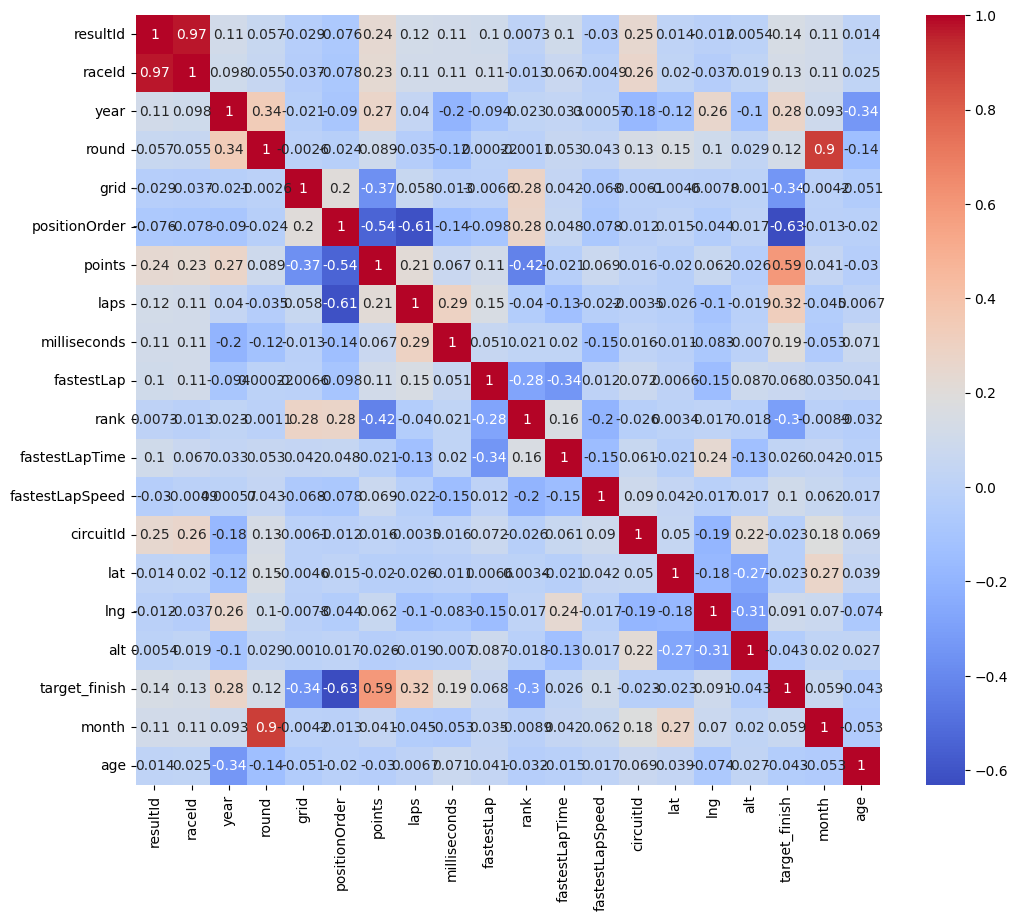

In [25]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot = True,cmap='coolwarm')
plt.show()

**heatmaps can be used for:**

1. To remove redundancy (corr between features)
2. To find useful predictors (corr between features and target)


In [26]:
corr = df.corr(numeric_only=True)
target_corr = corr['target_finish'].sort_values(ascending=False)
print(target_corr)

target_finish      1.000000
points             0.594568
laps               0.322128
year               0.276936
milliseconds       0.194938
resultId           0.144010
raceId             0.130897
round              0.123115
fastestLapSpeed    0.103055
lng                0.090647
fastestLap         0.067781
month              0.058813
fastestLapTime     0.025701
circuitId         -0.023277
lat               -0.023301
age               -0.043195
alt               -0.043222
rank              -0.304660
grid              -0.344964
positionOrder     -0.632000
Name: target_finish, dtype: float64


features giving corr near 0 are useless and that at extremes are useful..

therefore features like alt, lat , lng, circuitId,
fastestLapTime, raceId, resultId, round, fastestLapSpeed are
redundant

and rest are useful.

In [27]:
df['dob'] = pd.to_datetime(df['dob'])
df['dob'].dtype
df['age'] = df['date'].dt.year - df['dob'].dt.year
df.age

,age
0,23
1,35
2,28
3,22
4,25
...,...
9995,25
9996,34
9997,24
9998,27


In [28]:
df.drop('date',axis = 1,inplace=True)
df.drop(['dob','fastestLapTime','circuitId','resultId','raceId','month','alt','lat','lng'],axis = 1,inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             10000 non-null  int64  
 1   round            10000 non-null  int64  
 2   grid             10000 non-null  int64  
 3   positionOrder    10000 non-null  int64  
 4   points           10000 non-null  float64
 5   laps             10000 non-null  float64
 6   milliseconds     10000 non-null  float64
 7   fastestLap       10000 non-null  float64
 8   rank             10000 non-null  float64
 9   fastestLapSpeed  10000 non-null  float64
 10  driverRef        10000 non-null  object 
 11  surname          10000 non-null  object 
 12  forename         10000 non-null  object 
 13  nationality_x    10000 non-null  object 
 14  constructorRef   10000 non-null  object 
 15  name             10000 non-null  object 
 16  nationality_y    10000 non-null  object 
 17  circuitRef   

In [30]:
cat_col = df.select_dtypes(include=['object','category']).columns
print(cat_col)

Index(['driverRef', 'surname', 'forename', 'nationality_x', 'constructorRef',
       'name', 'nationality_y', 'circuitRef', 'name_y', 'location', 'country'],
      dtype='object')


In [31]:
df[['driverRef', 'surname', 'forename', 'nationality_x', 'constructorRef',
       'name', 'nationality_y', 'circuitRef', 'name_y', 'location', 'country']]

,driverRef,surname,forename,nationality_x,constructorRef,name,nationality_y,circuitRef,name_y,location,country
0,raikkonen,Räikkönen,Kimi,Finnish,mclaren,Hungaroring,British,hungaroring,McLaren,Budapest,Hungary
1,watson,Watson,John,British,mclaren,Long Beach,British,long_beach,McLaren,California,USA
2,ruttman,Ruttman,Troy,American,maserati,Nürburgring,Italian,nurburgring,Maserati,Nürburg,Germany
3,mick_schumacher,Schumacher,Mick,German,haas,Red Bull Ring,American,red_bull_ring,Haas F1 Team,Spielberg,Austria
4,modena,Modena,Stefano,Italian,eurobrun,Autodromo Nazionale di Monza,Italian,monza,Euro Brun,Monza,Italy
...,...,...,...,...,...,...,...,...,...,...,...
9995,doornbos,Doornbos,Robert,Dutch,red_bull,Autódromo José Carlos Pace,Austrian,interlagos,Red Bull,São Paulo,Brazil
9996,barrichello,Barrichello,Rubens,Brazilian,honda,Albert Park Grand Prix Circuit,Japanese,albert_park,Honda,Melbourne,Australia
9997,kevin_magnussen,Magnussen,Kevin,Danish,renault,Silverstone Circuit,French,silverstone,Renault,Silverstone,UK
9998,kennedy,Kennedy,Dave,Irish,shadow,Long Beach,British,long_beach,Shadow,California,USA


you can remove name_y (same as constructorRef)



In [32]:
df.drop('name_y',axis = 1,inplace=True)

In [33]:
df.drop('surname',axis = 1,inplace=True)

In [34]:
df.drop('forename',axis = 1,inplace=True)

In [35]:
df.drop('country',axis=1,inplace=True) #highly correlated to location

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             10000 non-null  int64  
 1   round            10000 non-null  int64  
 2   grid             10000 non-null  int64  
 3   positionOrder    10000 non-null  int64  
 4   points           10000 non-null  float64
 5   laps             10000 non-null  float64
 6   milliseconds     10000 non-null  float64
 7   fastestLap       10000 non-null  float64
 8   rank             10000 non-null  float64
 9   fastestLapSpeed  10000 non-null  float64
 10  driverRef        10000 non-null  object 
 11  nationality_x    10000 non-null  object 
 12  constructorRef   10000 non-null  object 
 13  name             10000 non-null  object 
 14  nationality_y    10000 non-null  object 
 15  circuitRef       10000 non-null  object 
 16  location         10000 non-null  object 
 17  target_finish

In [37]:
cat_col = df.select_dtypes(include=['object','category']).columns
for col in cat_col:
  unq_val = df[col].nunique()
  print(f"{col} has {unq_val} unique values")

driverRef has 677 unique values
nationality_x has 40 unique values
constructorRef has 174 unique values
name has 77 unique values
nationality_y has 21 unique values
circuitRef has 77 unique values
location has 75 unique values


for hig/med cardinality we'll use frequency encoding


In [38]:
freq_enc_col = df.select_dtypes(include=['object','category']).columns
for col in freq_enc_col:
  freq_map = df[col].value_counts()/len(df) # counts the freq of categories
  df[col] = df[col].map(freq_map) # replaces those categories with its freq thereby converting it to numeric

In [39]:
df.head()

,year,round,grid,positionOrder,points,laps,milliseconds,fastestLap,rank,fastestLapSpeed,driverRef,nationality_x,constructorRef,name,nationality_y,circuitRef,location,target_finish,age
0,2002,13,11,4,3.0,77.0,5788651.0,46.0,10.0,204.668,0.0144,0.0474,0.0728,0.0362,0.4504,0.0362,0.0362,1,23
1,1981,1,23,21,0.0,16.0,5788651.0,46.0,10.0,204.668,0.0064,0.1650,0.0728,0.0090,0.4504,0.0090,0.0100,0,35
2,1958,8,0,26,0.0,0.0,5788651.0,46.0,10.0,204.668,0.0005,0.0495,0.0170,0.0356,0.2191,0.0356,0.0356,0,28
3,2021,8,19,16,0.0,69.0,5788651.0,57.0,16.0,222.052,0.0015,0.0888,0.0151,0.0330,0.0354,0.0330,0.0330,0,22
4,1988,12,0,30,0.0,0.0,5788651.0,46.0,10.0,204.668,0.0039,0.1298,0.0041,0.0678,0.2191,0.0678,0.0678,0,25


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             10000 non-null  int64  
 1   round            10000 non-null  int64  
 2   grid             10000 non-null  int64  
 3   positionOrder    10000 non-null  int64  
 4   points           10000 non-null  float64
 5   laps             10000 non-null  float64
 6   milliseconds     10000 non-null  float64
 7   fastestLap       10000 non-null  float64
 8   rank             10000 non-null  float64
 9   fastestLapSpeed  10000 non-null  float64
 10  driverRef        10000 non-null  float64
 11  nationality_x    10000 non-null  float64
 12  constructorRef   10000 non-null  float64
 13  name             10000 non-null  float64
 14  nationality_y    10000 non-null  float64
 15  circuitRef       10000 non-null  float64
 16  location         10000 non-null  float64
 17  target_finish

before scaling and applying pca we'll just check how does it perform on Random Forest

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [42]:
X = df.drop('target_finish',axis = 1)
y = df['target_finish']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #splitting 80 20
#what does random state do??

In [44]:
tf = RandomForestClassifier(
    n_estimators=60,
    max_depth=5, # Im not sure if i should keep this 'None' may lead to overfitting
    random_state=42
)
tf.fit(X_train,y_train)
y_pred = tf.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.963


before applying pca we'll standardize the dataset

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [46]:
df_scaled

array([[ 0.52511476,  0.87702967, -0.02433485, ...,  0.32331674,
         1.56659868, -1.29742371],
       [-0.52178462, -1.48274433,  1.63297586, ..., -1.06340919,
        -0.63832557,  0.93265687],
       [-1.6683887 , -0.10620949, -1.54353632, ...,  0.29155966,
        -0.63832557, -0.36822347],
       ...,
       [ 1.22304768,  0.28708617,  0.66621128, ...,  1.2072222 ,
        -0.63832557, -1.11158367],
       [-0.57163697, -0.89280083, -1.54353632, ..., -1.06340919,
        -0.63832557, -0.55406352],
       [-0.77104638,  1.07367751, -1.54353632, ..., -1.20631606,
        -0.63832557,  0.56097677]])

this is the dataset in numpy array that we''ll use for pca

In [47]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10) #explains 95% of variance that could include any number of features

In [48]:
X_pca = pca.fit_transform(X)

In [49]:
X_pca.shape

(10000, 10)

In [50]:
X_pca

array([[-1.13509069e+05,  3.30258334e+01,  6.13924438e+00, ...,
        -6.74470034e+00,  2.51316244e+00, -1.51242213e+00],
       [-1.13509069e+05, -3.24911393e+01, -7.58974121e+00, ...,
         5.91299993e+00, -6.56153775e+00,  2.54847055e+00],
       [-1.13509069e+05, -5.25733224e+01, -2.58962393e+01, ...,
        -5.57907538e+00,  1.99698357e+00,  1.19374953e+00],
       ...,
       [-1.13509069e+05,  5.62241486e+00,  2.33479421e+01, ...,
        -2.77657549e+00, -1.25851959e+00, -6.83787780e-01],
       [-1.13509070e+05, -4.90664769e+01, -4.70942134e+00, ...,
        -3.55894951e+00, -3.72300353e+00, -4.91576490e-02],
       [-1.13509069e+05,  1.61219496e+00, -1.63564710e+01, ...,
         5.43927143e-01,  8.45363862e+00,  3.29137657e+00]])

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [52]:
X_train , X_test , y_train , y_test = train_test_split(X_pca,y,test_size=0.2)
log_reg = LogisticRegression(random_state = 42,solver = 'liblinear',max_iter=1000)
log_reg.fit(X_train,y_train)
y_pred = log_reg.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.6915
